#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> What is the stock gap (Supply - Demand) for each product? Which products are overstocked and which are understocked?

> Which warehouse has the highest total inventory value (Stock × Unit Price)?

> What is the correlation between Demand and Supply across all products?

> Create a pivot table showing average Demand per Product Category per Warehouse.

> Which product category has the highest average stock gap?

In [2]:
# Supply chain data for Vikram's warehouse operations
data = {
    'Product_ID': ['P001','P002','P003','P004','P005','P006','P007','P008','P009',
                   'P010','P011','P012','P013','P014','P015','P016','P017','P018'],

    'Product_Name': ['Rice','Wheat','Sugar','Oil','Salt',
                     'Shampoo','Soap','Toothpaste','Face Cream',
                     'Notebook','Pen','Stapler','Eraser',
                     'T-Shirt','Jeans','Jacket','Socks','Cap'],

    'Category': ['Grocery','Grocery','Grocery','Grocery','Grocery',
                 'Personal Care','Personal Care','Personal Care','Personal Care',
                 'Stationery','Stationery','Stationery','Stationery',
                 'Clothing','Clothing','Clothing','Clothing','Clothing'],

    'Warehouse': ['WH-A','WH-B','WH-A','WH-C','WH-B',
                  'WH-A','WH-C','WH-B','WH-A',
                  'WH-C','WH-B','WH-A','WH-C',
                  'WH-B','WH-A','WH-C','WH-B','WH-A'],

    'Supply': [500,420,380,210,600,150,200,180,90,
               300,450,120,200,80,60,40,150,100],

    'Demand': [480,500,300,250,580,180,160,200,110,
               280,400,100,220,100,80,30,120,90],

    'Unit_Price': [40,35,55,120,10,80,30,60,200,
                   15,5,100,8,299,799,1499,49,149]
}

#### `Step 1 :- Load and Explore Data`

In [3]:
# Convert to DataFrame
data_frame = pd.DataFrame(data)

data_frame

,Product_ID,Product_Name,Category,Warehouse,Supply,Demand,Unit_Price
0,P001,Rice,Grocery,WH-A,500,480,40
1,P002,Wheat,Grocery,WH-B,420,500,35
2,P003,Sugar,Grocery,WH-A,380,300,55
3,P004,Oil,Grocery,WH-C,210,250,120
4,P005,Salt,Grocery,WH-B,600,580,10
5,P006,Shampoo,Personal Care,WH-A,150,180,80
6,P007,Soap,Personal Care,WH-C,200,160,30
7,P008,Toothpaste,Personal Care,WH-B,180,200,60
8,P009,Face Cream,Personal Care,WH-A,90,110,200
9,P010,Notebook,Stationery,WH-C,300,280,15


#### `Step 2 :- Calculate Stock Gap`

In [4]:
# Supply - Demand = Stock Gap
data_frame['Stock_Gap'] = data_frame['Supply'] - data_frame['Demand']

data_frame

,Product_ID,Product_Name,Category,Warehouse,Supply,Demand,Unit_Price,Stock_Gap
0,P001,Rice,Grocery,WH-A,500,480,40,20
1,P002,Wheat,Grocery,WH-B,420,500,35,-80
2,P003,Sugar,Grocery,WH-A,380,300,55,80
3,P004,Oil,Grocery,WH-C,210,250,120,-40
4,P005,Salt,Grocery,WH-B,600,580,10,20
5,P006,Shampoo,Personal Care,WH-A,150,180,80,-30
6,P007,Soap,Personal Care,WH-C,200,160,30,40
7,P008,Toothpaste,Personal Care,WH-B,180,200,60,-20
8,P009,Face Cream,Personal Care,WH-A,90,110,200,-20
9,P010,Notebook,Stationery,WH-C,300,280,15,20


#### `Step 3 :- Assign Stock Status`

In [5]:
# Overstocked if gap > 0, Understocked if gap < 0, Balanced if gap == 0
data_frame['Stock_Status'] = np.where(data_frame['Stock_Gap'] > 0, 'Overstocked', np.where(data_frame['Stock_Gap'] < 0, 'Understocked', 'Balanced'))

data_frame

,Product_ID,Product_Name,Category,Warehouse,Supply,Demand,Unit_Price,Stock_Gap,Stock_Status
0,P001,Rice,Grocery,WH-A,500,480,40,20,Overstocked
1,P002,Wheat,Grocery,WH-B,420,500,35,-80,Understocked
2,P003,Sugar,Grocery,WH-A,380,300,55,80,Overstocked
3,P004,Oil,Grocery,WH-C,210,250,120,-40,Understocked
4,P005,Salt,Grocery,WH-B,600,580,10,20,Overstocked
5,P006,Shampoo,Personal Care,WH-A,150,180,80,-30,Understocked
6,P007,Soap,Personal Care,WH-C,200,160,30,40,Overstocked
7,P008,Toothpaste,Personal Care,WH-B,180,200,60,-20,Understocked
8,P009,Face Cream,Personal Care,WH-A,90,110,200,-20,Understocked
9,P010,Notebook,Stationery,WH-C,300,280,15,20,Overstocked


#### `Step 4 :- Calculate Inventory Value`

In [6]:
# Inventory Value = Supply × Unit Price
data_frame['Inventory_Value'] = data_frame['Supply'] * data_frame['Unit_Price']

data_frame

,Product_ID,Product_Name,Category,Warehouse,Supply,Demand,Unit_Price,Stock_Gap,Stock_Status,Inventory_Value
0,P001,Rice,Grocery,WH-A,500,480,40,20,Overstocked,20000
1,P002,Wheat,Grocery,WH-B,420,500,35,-80,Understocked,14700
2,P003,Sugar,Grocery,WH-A,380,300,55,80,Overstocked,20900
3,P004,Oil,Grocery,WH-C,210,250,120,-40,Understocked,25200
4,P005,Salt,Grocery,WH-B,600,580,10,20,Overstocked,6000
5,P006,Shampoo,Personal Care,WH-A,150,180,80,-30,Understocked,12000
6,P007,Soap,Personal Care,WH-C,200,160,30,40,Overstocked,6000
7,P008,Toothpaste,Personal Care,WH-B,180,200,60,-20,Understocked,10800
8,P009,Face Cream,Personal Care,WH-A,90,110,200,-20,Understocked,18000
9,P010,Notebook,Stationery,WH-C,300,280,15,20,Overstocked,4500


#### `Step 5 :- Total Inventory Value by Warehouse`

In [7]:
# Group by Warehouse and sum inventory values
warehouse_value = data_frame.groupby('Warehouse')['Inventory_Value'].sum()

warehouse_value

Warehouse
WH-A    145740
WH-B     65020
WH-C     97260
Name: Inventory_Value, dtype: int64

#### `Step 6 :- Correlation between Demand and Supply`

In [8]:
# Check correlation between Supply and Demand columns
correlation = data_frame[['Supply', 'Demand']].corr()

correlation

,Supply,Demand
Supply,1.000000,0.974462
Demand,0.974462,1.000000


#### `Step 7 :- Pivot Table — Average Demand per Category per Warehouse`

In [9]:
# Create pivot table to show average demand by category and warehouse
pivot = pd.pivot_table(data_frame, values = 'Demand', index = 'Category', columns = 'Warehouse', aggfunc = 'mean').round(2)

pivot

Warehouse,WH-A,WH-B,WH-C
Category,,,
Clothing,85.0,110.0,30.0
Grocery,390.0,540.0,250.0
Personal Care,145.0,200.0,160.0
Stationery,100.0,400.0,250.0


#### `Step 8 :- Average Stock Gap by Category`

In [10]:
# Calculate mean stock gap for each product category
category_gap = data_frame.groupby('Category')['Stock_Gap'].mean().round(2)

category_gap

Category
Clothing          2.0
Grocery           0.0
Personal Care    -7.5
Stationery       17.5
Name: Stock_Gap, dtype: float64

#### `Step 9 :- Chart 1 — Stock Gap by Product (sorted, color-coded)`

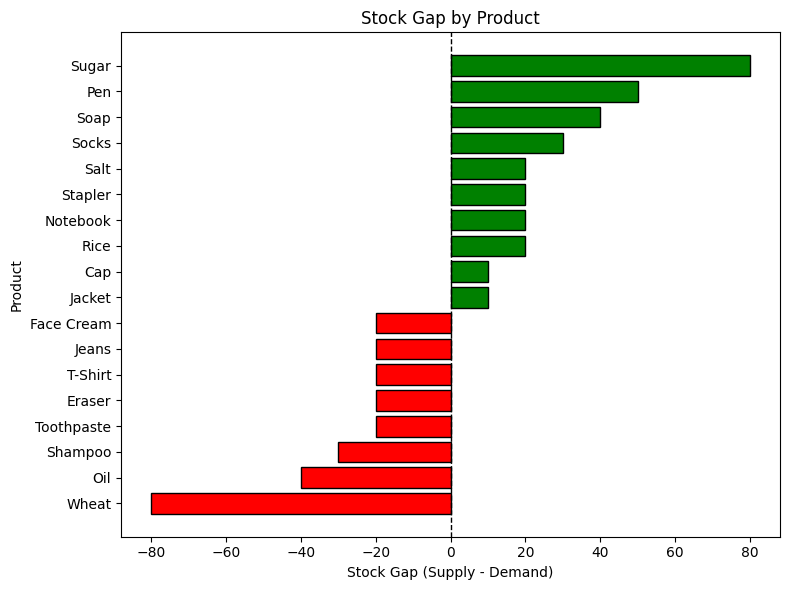

In [11]:
# Horizontal bar chart showing stock gap per product (color-coded)
data_frame_sorted = data_frame.sort_values('Stock_Gap')

colors = data_frame_sorted['Stock_Gap'].apply(lambda x: 'green' if x > 0 else ('red' if x < 0 else 'gray'))

plt.figure(figsize = (8, 6))

plt.barh(data_frame_sorted['Product_Name'], data_frame_sorted['Stock_Gap'], color = colors, edgecolor = 'black')

plt.axvline(x = 0, color = 'black', linewidth = 1, linestyle = '--')    # reference line at zero

plt.title('Stock Gap by Product')

plt.xlabel('Stock Gap (Supply - Demand)')

plt.ylabel('Product')

plt.tight_layout()

plt.savefig('5_Insights_Stock_Gap_by_Product.png')

plt.show()

#### `Step 10 :- Chart 2 — Total Inventory Value by Warehouse`

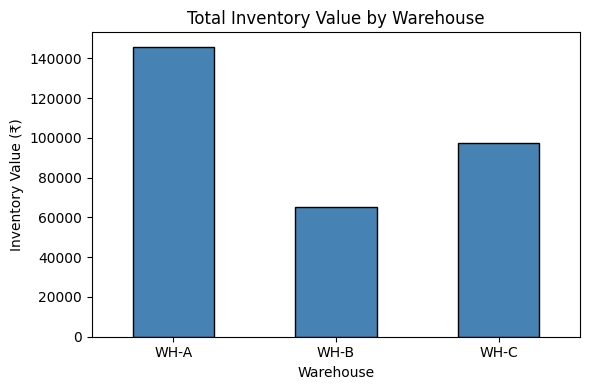

In [12]:
# Bar chart showing total inventory value per warehouse
plt.figure(figsize = (6, 4))

warehouse_value.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black')

plt.title('Total Inventory Value by Warehouse')

plt.xlabel('Warehouse')

plt.ylabel('Inventory Value (₹)')

plt.xticks(rotation = 0)

plt.tight_layout()

plt.savefig('5_Insights_Inventory_Value_by_Warehouse.png')

plt.show()

#### `Step 11 :- Print Outputs`

In [14]:
print(f'\nStock Gap and Status:\n{data_frame[['Product_Name', 'Stock_Gap', 'Stock_Status']]}')

print(f'\nTotal Inventory Value by Warehouse:\n{warehouse_value}')

print(f'\nCorrelation between Supply and Demand:\n{correlation}')

print(f'\nPivot Table - Average Demand per Category per Warehouse:\n{pivot}')

print(f'\nAverage Stock Gap by Category:\n{category_gap}')

print(f"\nStock Status Count:\n{data_frame['Stock_Status'].value_counts()}")    # Count of products by stock status


Stock Gap and Status:
   Product_Name  Stock_Gap  Stock_Status
0          Rice         20   Overstocked
1         Wheat        -80  Understocked
2         Sugar         80   Overstocked
3           Oil        -40  Understocked
4          Salt         20   Overstocked
5       Shampoo        -30  Understocked
6          Soap         40   Overstocked
7    Toothpaste        -20  Understocked
8    Face Cream        -20  Understocked
9      Notebook         20   Overstocked
10          Pen         50   Overstocked
11      Stapler         20   Overstocked
12       Eraser        -20  Understocked
13      T-Shirt        -20  Understocked
14        Jeans        -20  Understocked
15       Jacket         10   Overstocked
16        Socks         30   Overstocked
17          Cap         10   Overstocked

Total Inventory Value by Warehouse:
Warehouse
WH-A    145740
WH-B     65020
WH-C     97260
Name: Inventory_Value, dtype: int64

Correlation between Supply and Demand:
          Supply    Demand
Sup

#### `Information`
> Rows: 18

> Columns: 10 (Product_ID, Product_Name, Category, Warehouse, Supply, Demand, Unit_Price, Stock_Gap, Stock_Status, Inventory_Value)

> No missing values

#### `Data Insights`
> WH-A has highest inventory value = ₹1,45,740.

> Correlation between Supply & Demand = 0.97 (near-perfect alignment).

> Pivot table shows:

>>  Grocery demand peaks in WH-B (540).

>> Stationery demand in WH-B (400) is 4× higher than WH-A (100).

>> WH-C consistently lowest across all categories.

> Stationery category has highest avg stock gap (+17.5).

#### `Business Insights`
> WH-A holds maximum inventory → CFO’s capital concentrated there.

> Strong correlation (0.97) shows supply planning is nearly perfect.

> Stationery excess stock → slow-moving inventory.

> WH-C consistently lowest demand → underutilized warehouse.

#### `Risks`
> Overstock in Stationery and Grocery → capital lock, wastage risk.

> Understock in Personal Care → lost sales, customer dissatisfaction.

> Concentration of inventory value in WH-A → financial exposure.

#### `Opportunities`
> Reduce Stationery stock to free capital.

> Increase Personal Care supply to meet demand.

> Balance inventory across warehouses to reduce risk.

#### `Recommendations`
> Reduce Stationery overstock by 30% → frees ₹6,105 capital.

> Increase Personal Care supply → capture ₹7,600 missed revenue.

> Reallocate WH-A excess stock to balance warehouses.

> Use demand forecasting to prevent future imbalances.

#### `Expected Business Impact`
> Better stock balance → reduced capital lock.

> Improved supply-demand match → higher sales.

> Optimized warehouse allocation → lower financial risk.

#### `Future Prediction`
> If overstock not reduced, CFO’s concern will worsen.

> Personal Care demand will continue rising → needs proactive supply.

> Stationery may remain slow-moving unless promotions introduced.